multi-variable Linear Regression


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


In [25]:
df=pd.read_csv("homeprices2.csv")

In [26]:
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,NaN,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,4100,6.0,8,810000


In [27]:
df.bedrooms=df.bedrooms.fillna(df.bedrooms.mean())

In [28]:
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,4.2,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,4100,6.0,8,810000


In [29]:
x=df.drop("price",axis=1)

In [30]:
x

,area,bedrooms,age
0,2600,3.0,20
1,3000,4.0,15
2,3200,4.2,18
3,3600,3.0,30
4,4000,5.0,8
5,4100,6.0,8


In [31]:
y=df.price

In [32]:
y

0    550000
1    565000
2    610000
3    595000
4    760000
5    810000
Name: price, dtype: int64

In [33]:
model=LinearRegression()

In [34]:
model.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [35]:
model.predict([[5,4100,6]])

c:\Users\priya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([77110895.93349977])

In [36]:
model.score(x,y)

0.9540926625396438

In [37]:
#y=m1x1+m2x2+m3x3+b
m=model.coef_
b=model.intercept_

In [38]:
m


array([  116.66950551, 18756.28806982, -3675.75111708])

In [39]:
b


np.float64(231586.0063940914)

In [40]:
y=(m[0]*5)+(m[1]*4100)+(m[2]*6)

In [41]:
y

np.float64(76879309.9271057)

In [42]:
y_pred=model.predict(x)

In [43]:
y_pred

array([517680.56257679, 601483.40843428, 617541.31379815, 597592.55691169,
       762639.45982935, 793062.69844975])

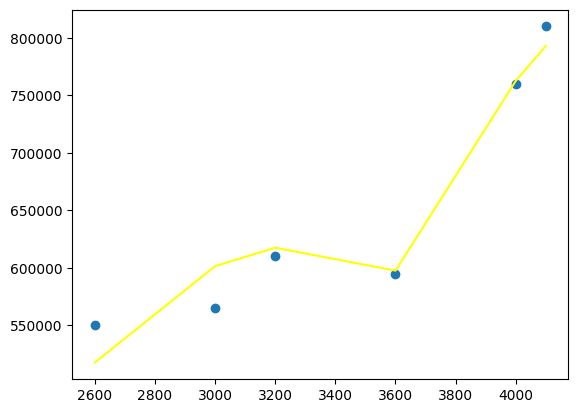

In [44]:
plt.scatter(df.area,df.price)
plt.plot(df.area,y_pred,color="yellow")

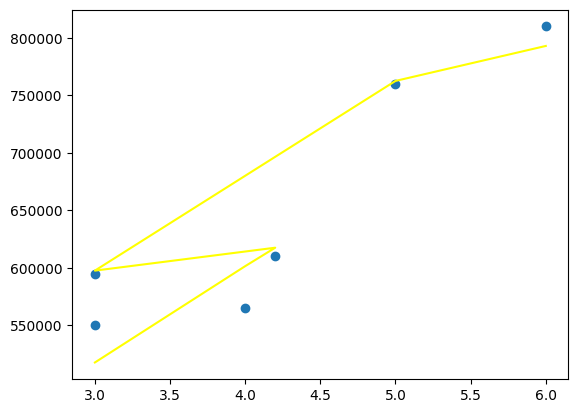

In [45]:
plt.scatter(df.bedrooms,df.price)
plt.plot(df.bedrooms,y_pred,color="yellow")

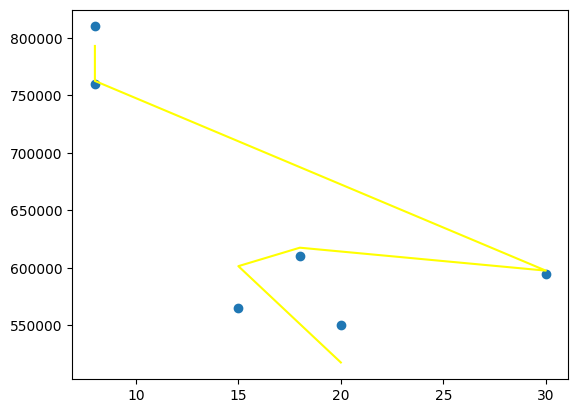

In [46]:
plt.scatter(df.age,df.price)
plt.plot(df.age,y_pred,color="yellow")

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [48]:
df2=pd.read_csv("hiring.csv")

In [49]:
df2


,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,NaN,7,72000
7,eleven,7.0,8,80000


In [50]:
exp_map={
    "one":1,
    "two":2,
    "three":3,
    "four":4,
    "five":5,
    "six":6,
    "seven":7,
    "eight":8,
    "nine":9,
    "ten":10,
    "eleven":11
}

In [51]:
df2.experience=df2.experience.map(exp_map).fillna(0).astype(int)

In [52]:
df2


,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,NaN,7,72000
7,11,7.0,8,80000


In [56]:
df2['test_score(out of 10)']=df2['test_score(out of 10)'].fillna(round(df2['test_score(out of 10)'].median()))

In [57]:
df2

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,8.0,7,72000
7,11,7.0,8,80000


In [58]:
x=df2.drop("salary($)",axis=1)

In [59]:
x

,experience,test_score(out of 10),interview_score(out of 10)
0,0,8.0,9
1,0,8.0,6
2,5,6.0,7
3,2,10.0,10
4,7,9.0,6
5,3,7.0,10
6,10,8.0,7
7,11,7.0,8


In [60]:
y=df2['salary($)']

In [61]:
y

0    50000
1    45000
2    60000
3    65000
4    70000
5    62000
6    72000
7    80000
Name: salary($), dtype: int64

In [63]:
model=LinearRegression()

In [64]:
model.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [65]:
model.predict([[3,7,10]])

c:\Users\priya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([61148.47161572])

In [67]:
model.score(x,y)

0.961678000257796

In [68]:
m=model.coef_
b=model.intercept_

In [69]:
m

array([2812.95487627, 1845.70596798, 2205.24017467])

In [70]:
b

np.float64(17737.26346433768)

In [71]:
y2=(m[0]*3)+(m[1]*7)+(m[2]*10)+b

In [72]:
y2

np.float64(61148.471615720526)

In [73]:
y_pred=model.predict(x)

In [74]:
y_pred

array([52350.0727802 , 45734.35225619, 58312.95487627, 63872.63464338,
       67270.74235808, 61148.47161572, 76069.1411936 , 79241.63027656])

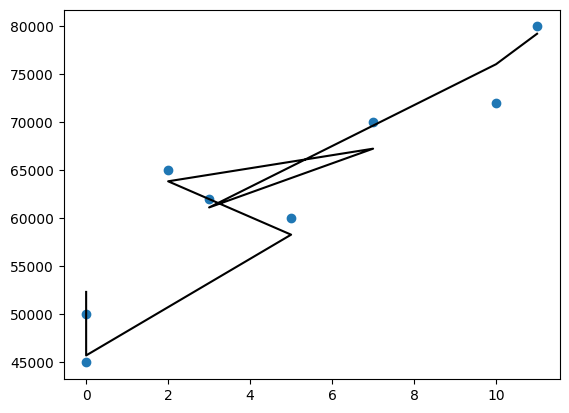

In [77]:
plt.scatter(df2.experience,df2['salary($)'])
plt.plot(df2.experience,y_pred,color="black")

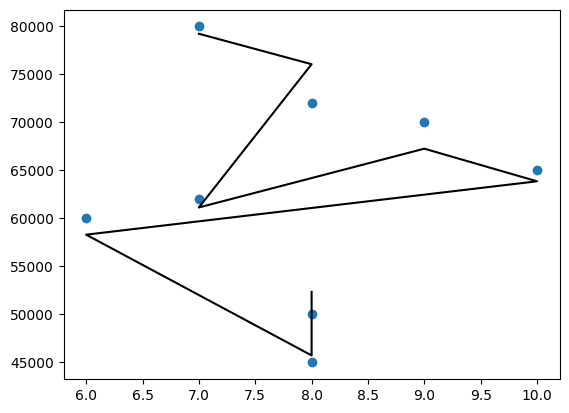

In [78]:
plt.scatter(df2['test_score(out of 10)'],df2['salary($)'])
plt.plot(df2['test_score(out of 10)'],y_pred,color="black")

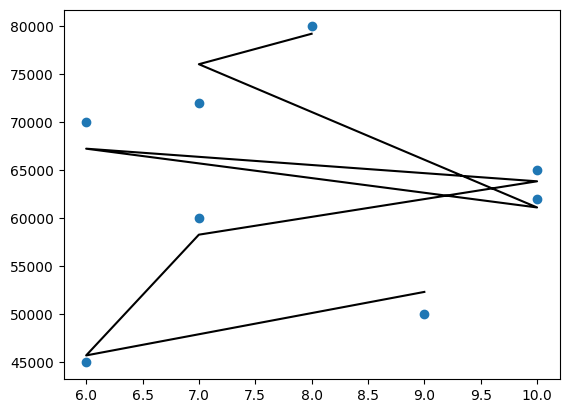

In [80]:
plt.scatter(df2['interview_score(out of 10)'],df2['salary($)'])
plt.plot(df2['interview_score(out of 10)'],y_pred,color="black")

In [81]:
model.predict([[6,4,5]])

c:\Users\priya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([53024.01746725])

In [82]:
y3=(m[0]*6)+(m[1]*4)+(m[2]*5)+b

In [83]:
y3

np.float64(53024.0174672489)